# Chapter 14 — Learned Initializers and Mandatory Physical Closure

*Stellar Spectroscopy from Scratch — from physical principles to
a working code*

Chapter 13 gave us the exact physical iteration and permits a
schema-v4 product only after structural convergence. It still
requires an explicit seed, and a poor seed can lie outside the
basin from which that iteration converges.

The solver is an iteration. Starting from a state
\(\mathbf{x}^{(0)}\), one physical pass produces

\[
\mathbf{x}^{(n+1)}=\mathcal G(\mathbf{x}^{(n)}).
\]

A converged atmosphere is a **fixed point**:

\[
\mathbf{x}_\star=\mathcal G(\mathbf{x}_\star).
\]

The distinction is small on the page and decisive in a program.
A learned model can propose a smooth, plausible
\(\mathbf{x}^{(0)}\). It cannot certify that radiative transfer,
hydrostatic balance, the equation of state, convection, and
chemistry all agree at that state.

This chapter asks:

> **How can we learn a useful starting atmosphere—including for
an unusual abundance mixture—without ever mistaking the proposal
for the physical answer?**

We will build the initializer in three layers. First comes the
common six-profile physical representation. Next come the ordinary
five-label and CNO-aware routes. Finally we add the experimental
direct-abundance route, whose strict provenance and
mandatory-closure rules are part of the algorithm rather than
optional documentation.

The three families share the target shape—six profiles on 80
layers—but not a trained decoder. Each checkpoint owns its label
normalization, network weights, coefficient scaling, coordinate
normalization, and PCA basis. Equal array dimensions do not make
those learned arrays interchangeable.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from book.chapter14_runtime import (
    FIVE_LABEL_EXAMPLE,
    asset_identity_checkpoint, candidate_checkpoint,
    closure_seam_checkpoint, decoder_checkpoint,
    direct_decoder_checkpoint, direct_mixture_checkpoint,
    direct_safety_checkpoint, direct_set_encoder_checkpoint,
    training_data_checkpoint, warm_start_checkpoint,
)
from book.chapter14_teaching import (
    PROFILE_FIELDS, fixed_point_contraction_trace,
    grey_temperature, pca_sentinel_trace,
    profile_transform_round_trip, quantize_centidex,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel

from book.chapter14_runtime import configure_chapter14_runtime
configure_chapter14_runtime()
from payne_zero_atmosphere.warm_start import (
    INITIALIZER_STANDARD_ROSSELAND_OPTICAL_DEPTH,
    resolve_cno8_labels,
)


<figure>
  <img src="assets/schematics/textbook/ch14-initializer-to-closure-v2.png"
       alt="Conceptual workflow in which five-label, CNO8, and direct-abundance requests pass through three separate family-owned normalization, network or set-encoder, coefficient-scaling, and PCA-basis bundles. The lanes share only the six-profile 80-layer output representation, which becomes an initialized proposal. A horizontal exact loop then runs populations, opacity, transfer, convection, correction and remap before structural convergence and independent checks can permit a schema-v4 physical atmosphere; a failed check begins the next pass.">
  <figcaption><strong>A learned start shortens the route; it does
  not replace the route.</strong> Five-label, CNO-aware, and
  experimental direct-abundance inputs use separate trained
  decoder bundles that end in the same six-profile representation.
  Every decoded atmosphere remains a proposal until the exact
  physical loop converges and its independent checks pass.
  </figcaption>
</figure>


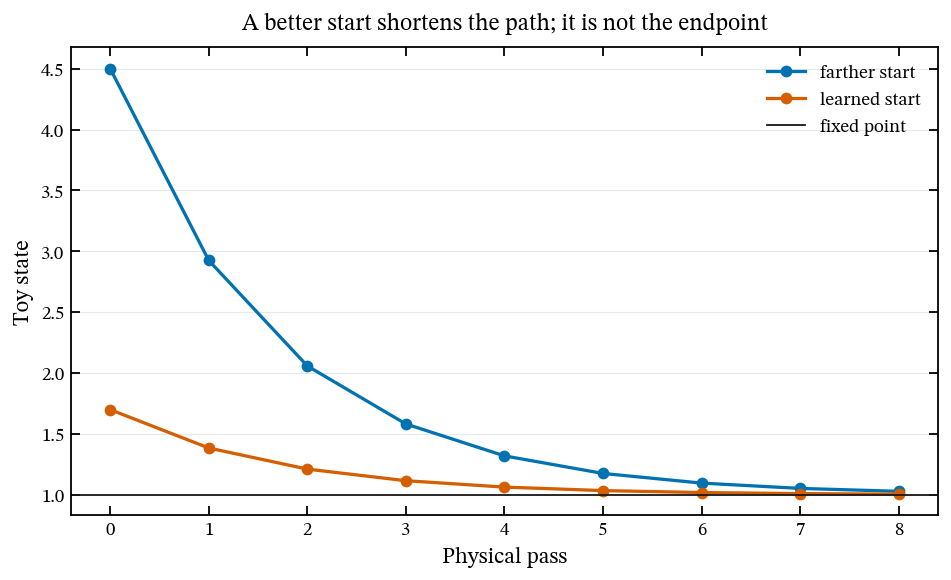

In [3]:
near = fixed_point_contraction_trace(1.7, contraction=0.55)
far = fixed_point_contraction_trace(4.5, contraction=0.55)
passes = np.arange(near.values.size)

figure, axes = single_panel()
axes.plot(passes, far.values, "o-", label="farther start")
axes.plot(passes, near.values, "o-", label="learned start")
axes.axhline(near.fixed_point, color=PAPER_COLORS["black"],
             linewidth=1.0, label="fixed point")
axes.set(xlabel="Physical pass", ylabel="Toy state",
         title="A better start shortens the path; it is not the endpoint")
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)


The scalar example is deliberately simple. Both trajectories use
the same map; only their starting values differ. The learned start
is useful because fewer physical passes are needed, not because
its first residual is zero.

For a scalar map, errors near the fixed point obey

\[
e^{(n+1)}\simeq \mathcal G'(x_\star)e^{(n)}.
\]

If \(|\mathcal G'(x_\star)|<1\), a nearby error shrinks. For a
many-variable atmosphere, the derivative becomes the Jacobian
\(\mathbf J_{\mathcal G}\); local convergence requires its largest
eigenvalue magnitude to be below one. The surrounding region from
which iteration reaches the fixed point is its **basin of
attraction**. Our initializer tries to land inside that basin.

## 14.1 One state means six depth profiles

An 80-layer starting atmosphere carries six predicted columns.
They have very different scales: temperature is measured in
thousands of kelvin, electron density may span many orders of
magnitude, and radiative acceleration can have either sign. A
network should not be asked to learn all six in their raw units.

The runtime bundle contains only inference checkpoints and their
manifests. Training examples are not needed to evaluate the
learned map.


In [4]:
identity = asset_identity_checkpoint()
print("initializer release:", identity.release)
print("ordinary features:", len(identity.five_label_features))
print("CNO-aware features:", len(identity.cno8_features))
print("training corpora packaged:", identity.training_corpora_packaged)
print("exact solver is final authority:",
      identity.exact_solver_is_final_authority)


initializer release: v1.3
ordinary features: 5
CNO-aware features: 8
training corpora packaged: False
exact solver is final authority: True


In [5]:
five = decoder_checkpoint("five_label")
for field in PROFILE_FIELDS:
    values = five.prediction[field]
    print(
        f"{field:24s} shape={str(values.shape):6s} "
        f"dtype={values.dtype} "
        f"range=({values.min():.3e}, {values.max():.3e})"
    )


column_mass              shape=(80,)  dtype=float64 range=(5.872e-04, 1.285e+01)
temperature              shape=(80,)  dtype=float64 range=(3.710e+03, 1.136e+04)
gas_pressure             shape=(80,)  dtype=float64 range=(1.610e+01, 3.432e+05)
electron_density         shape=(80,)  dtype=float64 range=(2.306e+09, 2.160e+16)
rosseland_opacity        shape=(80,)  dtype=float64 range=(2.270e-04, 2.927e+02)
radiative_acceleration   shape=(80,)  dtype=float64 range=(7.786e-02, 8.917e+00)


The first five profiles must be positive; column mass must also
increase inward. Radiative acceleration is signed. These
constraints suggest the coordinates

\[
\mathbf u_j=\left(
\log_{10}\Delta m_j,\,
\log_{10}\frac{T_j}{T_{{\rm grey},j}},\,
\log_{10}P_{{\rm gas},j},\,
\log_{10}n_{e,j},\,
\log_{10}\kappa_{{\rm R},j},\,
\operatorname{asinh}\frac{g_{{\rm rad},j}}{s_g}
\right).
\]

Here \(\Delta m_0=m_0\) and
\(\Delta m_j=m_j-m_{j-1}\). Predicting a positive increment and
cumulatively summing it guarantees increasing column mass.
Logarithms turn positive quantities that span orders of magnitude
into moderate coordinates. The inverse hyperbolic sine behaves
roughly linearly near zero and logarithmically at large magnitude,
while preserving the sign of \(g_{\rm rad}\).

Temperature is measured relative to the grey-atmosphere scale

\[
T_{\rm grey}(\tau_{\rm R})=
T_{\rm eff}\left[\frac34\left(\tau_{\rm R}+\frac23\right)\right]^{1/4}.
\]

This reference supplies the broad outward-to-inward temperature
trend, leaving the network to learn the non-grey correction.


In [6]:
profile = np.column_stack(tuple(five.prediction.values()))
transform = profile_transform_round_trip(
    profile,
    effective_temperature=FIVE_LABEL_EXAMPLE["effective_temperature"],
    rosseland_optical_depth=INITIALIZER_STANDARD_ROSSELAND_OPTICAL_DEPTH,
    acceleration_scale=five.acceleration_scale,
)
for field, error in zip(
    PROFILE_FIELDS, transform.maximum_relative_difference, strict=True
):
    print(f"{field:24s} maximum relative round-trip error = {error:.2e}")


column_mass              maximum relative round-trip error = 0.00e+00
temperature              maximum relative round-trip error = 0.00e+00
gas_pressure             maximum relative round-trip error = 0.00e+00
electron_density         maximum relative round-trip error = 0.00e+00
rosseland_opacity        maximum relative round-trip error = 0.00e+00
radiative_acceleration   maximum relative round-trip error = 2.07e-16


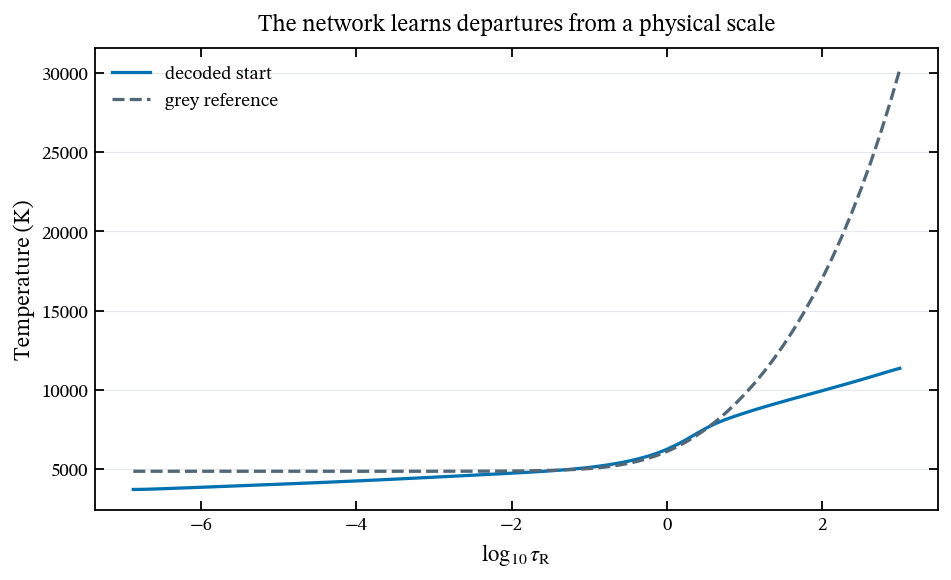

In [7]:
log_tau = np.log10(INITIALIZER_STANDARD_ROSSELAND_OPTICAL_DEPTH)
grey = grey_temperature(
    FIVE_LABEL_EXAMPLE["effective_temperature"],
    INITIALIZER_STANDARD_ROSSELAND_OPTICAL_DEPTH,
)
figure, axes = single_panel()
axes.plot(log_tau, five.prediction["temperature"],
          label="decoded start")
axes.plot(log_tau, grey, "--", color=PAPER_COLORS["slate"],
          label="grey reference")
axes.set(xlabel=r"$\log_{10}\tau_{\rm R}$",
         ylabel="Temperature (K)",
         title="The network learns departures from a physical scale")
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)


## 14.2 Why 480 numbers are not 480 independent numbers

Before compressing anything, it is worth seeing why compression is
possible at all. Six coordinates at eighty layers is 480 numbers,
but they are nowhere near free to vary independently. Temperature
rises monotonically inward and, from Chapter 1, follows something
close to the grey law. Pressure is then pinned by hydrostatic
balance, and density follows from pressure and temperature through
the equation of state. The physics of the preceding thirteen
chapters is precisely a set of constraints among these columns. A
real atmosphere is a smooth, tightly coupled object living on a
thin surface inside a 480-dimensional space.

Principal-component analysis is the standard way to find that
surface without being told where it is. Collect \(N\) atmospheres
as the rows of a matrix \(\mathbf U\in\mathbb R^{N\times480}\),
subtract the column mean \(\overline{\mathbf u}\), and form the
covariance

\[
\mathbf C=\frac{1}{N}
  (\mathbf U-\overline{\mathbf u})^{\mathsf T}
  (\mathbf U-\overline{\mathbf u}).
\]

Its eigenvectors are orthogonal directions in the 480-dimensional
space, and each eigenvalue is the variance the training set
actually shows along its direction. Sorting by eigenvalue and
keeping the leading \(k\) rows as \(\mathbf B\) gives the best
possible \(k\)-dimensional linear summary in the least-squares
sense. Every atmosphere is then reconstructed as a mean plus a
short list of coefficients,

\[
\mathbf u\approx\overline{\mathbf u}+\mathbf c\,\mathbf B ,
\]

and the network only ever has to predict \(\mathbf c\).

One caveat carries the whole chapter. The discarded directions are
negligible *for the training distribution*, not in general. A
request that falls outside the region those atmospheres covered can
need exactly the directions PCA threw away, and the reconstruction
will still return a confident, smooth, entirely wrong profile —
with no internal signal that anything went missing. That is why
§14.8 insists the last arrow returns to physics, and why an
initializer output is never accepted as a converged atmosphere.

## 14.3 From 480 coordinates to 160 coefficients

We begin with the five-label checkpoint. The CNO8 and direct
checkpoints repeat the same *shape contract* with their own stored
normalization and PCA arrays.

Stacking six coordinates at each of 80 layers gives an
\((80,6)\) array. C-order flattening produces

\[
80\times 6=480
\]

coordinates: all six fields of layer zero, then all six of layer
one, and so on. Principal-component analysis (PCA) keeps 160
coefficients. If \(\widehat{\mathbf z}\) is the network output,

\[
\widehat{\mathbf c}
  =\overline{\mathbf c}
   +\mathbf s_c\odot\widehat{\mathbf z},
\]

followed in the stored array convention by

\[
\widehat{\mathbf u}_{\rm std}
  =\widehat{\mathbf c}\,\mathbf B,
\qquad \mathbf B\in\mathbb R^{160\times480}.
\]

The mathematical expression may instead write
\(\mathbf B^{\mathsf T}\widehat{\mathbf c}\) for column vectors.
The checkpoint shape, not typography, decides the code
orientation. A one-hot sentinel makes the flattening convention
testable.


In [8]:
sentinel = pca_sentinel_trace(
    component_index=7, layer_index=23, field_index=4
)
print("stored basis shape:       (160, 480)")
print("chosen flattened index: ", sentinel.flattened_index)
print("recovered layer:         ", sentinel.recovered_layer_index)
print("recovered field:         ", sentinel.recovered_field_index)


stored basis shape:       (160, 480)
chosen flattened index:  142
recovered layer:          23
recovered field:          4


The compact neural network is a sequence of affine layers and
SiLU activations. It evaluates in Torch `float32`, on a CPU or GPU.
Device tensors cross to CPU exactly once. Coefficient
de-standardization, PCA multiplication, reshape, and all six
physical inverse transforms then run in NumPy `float64`.

This is an explicit numerical boundary. Moving it would alter
rounding and therefore the starting columns delivered to the
exact solver.


In [9]:
print("network output:          ",
      five.standardized_coefficients.shape,
      five.standardized_coefficients.dtype)
print("de-standardized c:       ",
      five.pca_trace.coefficients.shape,
      five.pca_trace.coefficients.dtype)
print("reconstructed u:         ",
      five.pca_trace.standardized_coordinates.shape,
      five.pca_trace.standardized_coordinates.dtype)
print("reshaped coordinates:    ",
      five.pca_trace.coordinates.shape,
      five.pca_trace.coordinates.dtype)
print("independent decoder diff:",
      five.maximum_absolute_decode_difference)


network output:           (160,) float32
de-standardized c:        (160,) float64
reconstructed u:          (480,) float64
reshaped coordinates:     (80, 6) float64
independent decoder diff: 0.0


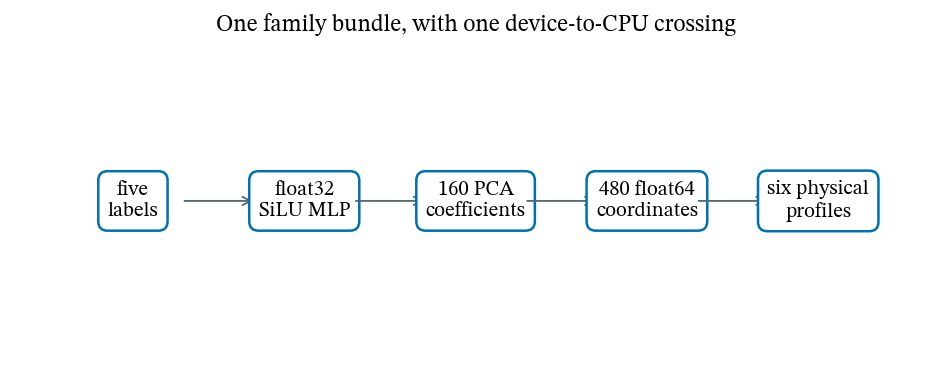

In [10]:
stages = ["five\nlabels", "float32\nSiLU MLP",
          "160 PCA\ncoefficients", "480 float64\ncoordinates",
          "six physical\nprofiles"]
figure, axes = single_panel(height=2.7)
for index, label in enumerate(stages):
    axes.text(index, 0.5, label, ha="center", va="center",
              bbox={"boxstyle": "round,pad=0.45", "facecolor": "white",
                    "edgecolor": PAPER_COLORS["blue"], "linewidth": 1.4})
    if index + 1 < len(stages):
        axes.annotate("", xy=(index + 0.72, 0.5),
                      xytext=(index + 0.28, 0.5),
                      arrowprops={"arrowstyle": "->",
                                  "color": PAPER_COLORS["slate"]})
axes.set(xlim=(-0.7, 4.7), ylim=(0.0, 1.0),
         title="One family bundle, with one device-to-CPU crossing")
axes.axis("off")
plt.show()
plt.close(figure)


During training, profile accuracy was supplemented by three
physical-consistency terms:

\[
\mathcal L=\mathcal L_{\rm prof}
+\lambda_\nabla\mathcal L_\nabla
+\lambda_\tau\mathcal L_\tau
+\lambda_{\rm hse}\mathcal L_{\rm hse}.
\]

The gradient term discourages wrong depth-to-depth structure. The
optical-depth term checks
\(d\tau_{\rm R}/dm=\kappa_{\rm R}\). The hydrostatic term checks
\(dP_{\rm gas}/dm\simeq g-g_{\rm rad}\). These terms improve the
proposal, but none is evaluated as a substitute for the exact
iteration at inference time.


In [11]:
config = five.model_config
parameter_count = (
    config["input_dim"] * config["width"] + config["width"]
    + (config["hidden_layers"] - 1)
      * (config["width"] ** 2 + config["width"])
    + config["width"] * config["output_dim"]
    + config["output_dim"]
)
print(f"SiLU hidden layers: {config['hidden_layers']}")
print(f"hidden width:      {config['width']}")
print(f"parameters:        {parameter_count:,}")
print("loss weights:      ",
      five.derivative_loss_weight,
      five.optical_depth_loss_weight,
      five.hydrostatic_loss_weight)


SiLU hidden layers: 6
hidden width:      1024
parameters:        5,418,144
loss weights:       0.1 0.05 0.05


To train this initializer from scratch, the order matters:

1. Run the exact physical solver over the chosen label domain and
   retain only finite, structurally converged 80-layer states.
2. Assign training, fit-validation, and internal-check identities
   deterministically. The fit-validation set selects the
   checkpoint; it is not an independent test set.
3. For each family separately, fit its label normalization, six
   coordinate normalizations, and 160-component PCA
   representation using only that family's training data.
4. Train the MLP to predict standardized PCA coefficients while
   evaluating the loss after physical decoding.
5. Select a checkpoint using fit-validation loss, inspect the
   untouched internal check, and then test the quantity that
   matters operationally: exact restart trajectories.
6. Serialize feature order, support, transforms, PCA arrays,
   architecture, weights, and hashes together. A weight file
   without those arrays is not the same model.

The split sizes below are provenance, not runtime data. The
direct-abundance set was generated from independent explicit
mixtures; it contains no recycled five-label or CNO rows.


In [12]:
training = training_data_checkpoint()
print(
    "five-label: "
    f"{training.five_label_train:,} train + "
    f"{training.five_label_fit_validation:,} fit-validation + "
    f"{training.five_label_internal_check:,} internal"
)
print(
    "CNO-aware:  "
    f"{training.cno8_frozen_train:,} frozen train + "
    f"{training.cno8_appended_training:,} appended train + "
    f"{training.cno8_fit_validation:,} fit-validation + "
    f"{training.cno8_internal_check:,} internal"
)
print(
    "direct:     "
    f"{training.direct_train:,} train + "
    f"{training.direct_fit_validation:,} fit-validation + "
    f"{training.direct_internal_check:,} internal + "
    f"{training.direct_unused_external_gate:,} unused gate"
)
print(
    "direct optimizer:",
    training.direct_optimizer,
    "learning rate", training.direct_learning_rate,
    "seed", training.direct_seed,
)


five-label: 50,000 train + 2,000 fit-validation + 199 internal
CNO-aware:  50,000 frozen train + 1,625 appended train + 2,000 fit-validation + 199 internal
direct:     71,660 train + 9,733 fit-validation + 313 internal + 310 unused gate
direct optimizer: AdamW learning rate 0.0007 seed 314159


## 14.4 Use the smallest label family that preserves the mixture

Most stars can be initialized by five quantities:

\[
(5040/T_{\rm eff},\,\log g,\,[{\rm M/H}],\,
  [\alpha/{\rm M}],\,\xi).
\]

Carbon, nitrogen, and oxygen strongly affect molecular chemistry.
If any of them is supplied explicitly, the five-label model cannot
represent the request. The route therefore switches to an
eight-feature model and appends
\([{\rm C/M}]\), \([{\rm N/M}]\), and \([{\rm O/M}]\).
There is no fallback that silently erases this information.

Missing C and N offsets default to zero; missing oxygen follows
\([\alpha/{\rm M}]\). An absolute abundance is converted through
\([{\rm X/M}]=[{\rm X/H}]-[{\rm M/H}]\).

Routing therefore selects a complete checkpoint bundle, not merely
a different input layer attached to a shared decoder. The
five-label and CNO8 bases both happen to have shape
\((160,480)\); their values and normalization arrays remain
family-specific.


In [13]:
candidates = candidate_checkpoint()
resolved = resolve_cno8_labels(
    metallicity=-0.7,
    alpha_enhancement=0.25,
    carbon_enhancement=0.2,
)
print("ordinary request ->", candidates.five_label_family)
print("relative C request ->", candidates.cno_relative_family)
print("absolute O request ->", candidates.cno_absolute_family)
print("resolved CNO labels:", resolved)


ordinary request -> five_label
relative C request -> cno8
absolute O request -> cno8
resolved CNO labels: {'carbon_enhancement': 0.2, 'nitrogen_enhancement': 0.0, 'oxygen_enhancement': 0.25}


The initializer has finite training support. For the ordinary and
CNO families, an out-of-support request is projected only for the
purpose of proposing a structure. The exact requested stellar
labels and abundances are retained in the deck and in the later
physical solve.

Restarts are deterministic. The first candidate is the requested
initializer label, or its nearest supported projection. Further
candidates add a 0.01-width jitter whose direction is derived from
SHA-256 of the full request, a fixed public seed, the trial number,
and the feature name. This produces the same ordered candidates
in every process without a mutable random-number stream.


In [14]:
for index, label in enumerate(candidates.projected_candidates):
    print(
        f"candidate {index}: "
        f"T_init={label['effective_temperature']:9.3f} K, "
        f"logg_init={label['log_surface_gravity']:.4f}"
    )
print("requested physical T_eff:",
      candidates.projected_request_temperature, "K")
print("repeat is identical:", candidates.deterministic)


candidate 0: T_init=10499.779 K, logg_init=4.4400
candidate 1: T_init=10376.221 K, logg_init=4.4034
candidate 2: T_init=10499.779 K, logg_init=4.4048
requested physical T_eff: 12000.0 K
repeat is identical: True


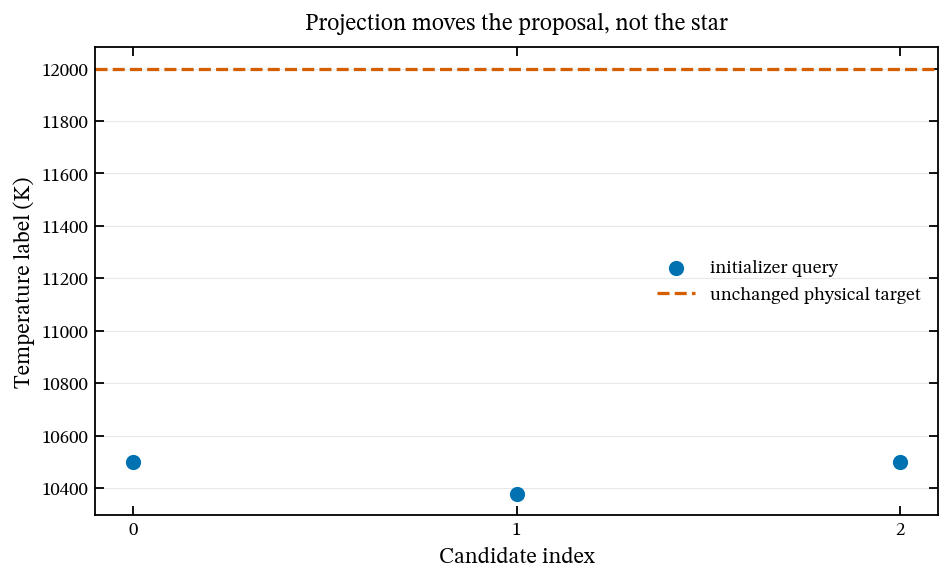

In [15]:
initializer_temperatures = [
    label["effective_temperature"]
    for label in candidates.projected_candidates
]
figure, axes = single_panel()
axes.scatter(range(len(initializer_temperatures)),
             initializer_temperatures, s=55,
             label="initializer query")
axes.axhline(candidates.projected_request_temperature,
             color=PAPER_COLORS["orange"], linestyle="--",
             label="unchanged physical target")
axes.set(xlabel="Candidate index", ylabel="Temperature label (K)",
         title="Projection moves the proposal, not the star")
axes.set_xticks(range(len(initializer_temperatures)))
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)


## 14.5 The deck boundary is part of the numerical method

The network predicts real-valued arrays, but the exact solver is
initialized through a historical fixed-column atmosphere deck.
Its finite number of printed digits quantizes every layer. The
in-memory path therefore performs the same operation as the file
path:

\[
\text{prediction}\longrightarrow
\text{fixed-column text}\longrightarrow
\texttt{ModelAtmosphere}.
\]

It is worth being explicit about why the in-memory route throws away
precision it already holds. If it kept full float64 while the file
route rounded, the same star would enter the solver in two different
states depending on how the code happened to be invoked, and the two
trajectories could converge to visibly different atmospheres. The
quantization is lossy, but it is *deterministic*, and reproducing it
makes the entry boundary a defined numerical operator rather than an
accident of plumbing.

This is the same argument Chapter 13 makes about \(Q\) at the far end
of the loop, applied at the near end. Chapter 13 keeps the iteration
unquantized and rounds exactly once on the way out; Chapter 14 rounds
exactly once on the way in. In both cases the rule is that a lossy
format operation may happen, but it must happen at a single declared
place, never inside the fixed-point map.

The formatter and parser run once per candidate before its first
physical pass. The resulting object has no `converged` field.
It is a starting atmosphere.


parsed target T_eff: 5777.0 K
has converged field: False


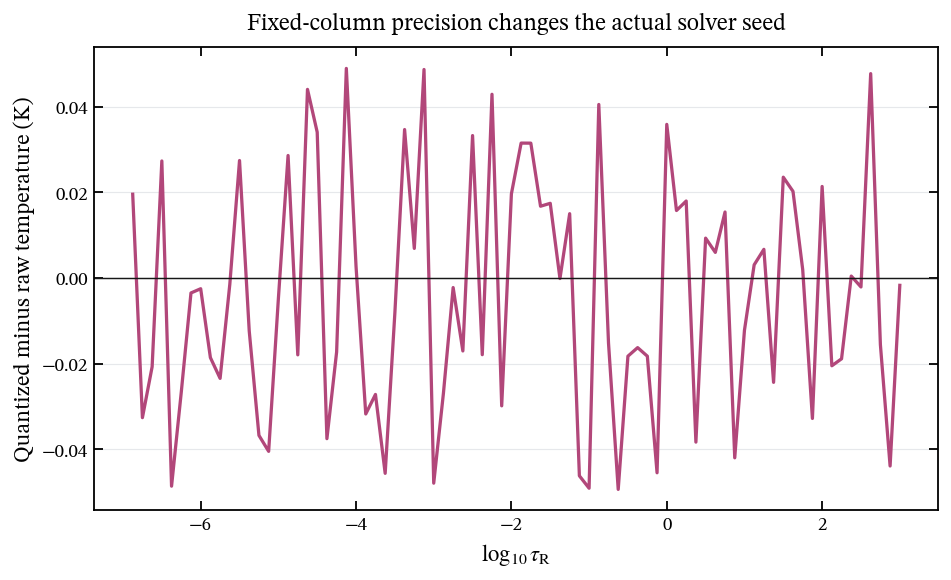

In [16]:
seed = warm_start_checkpoint("five_label")
delta_temperature = (
    seed.quantized_prediction["temperature"]
    - seed.raw_prediction["temperature"]
)
figure, axes = single_panel()
axes.plot(log_tau, delta_temperature,
          color=PAPER_COLORS["magenta"])
axes.axhline(0.0, color=PAPER_COLORS["black"], linewidth=0.8)
axes.set(xlabel=r"$\log_{10}\tau_{\rm R}$",
         ylabel="Quantized minus raw temperature (K)",
         title="Fixed-column precision changes the actual solver seed")
add_quiet_grid(axes, axis="y")
print("parsed target T_eff:", seed.parsed_effective_temperature, "K")
print("has converged field:", seed.has_converged_field)
plt.show()
plt.close(figure)


## 14.6 Direct abundances require a larger safety contract

Five or eight labels describe common correlated mixtures. They
cannot represent an arbitrary elemental pattern. The experimental
direct route instead begins with 81 public \([{\rm X/H}]\) values:
every element from atomic number 3 to 99 that has a finite solar
reference.

The network does not consume those 81 values directly. It uses 84
features:

\[
(5040/T_{\rm eff},\,\log g,\,\xi,\,[{\rm Fe/H}],
  \underbrace{[{\rm X/Fe}]_1,\ldots,
              [{\rm X/Fe}]_{80}}_{\text{all non-Fe public elements}}).
\]

The exact equation of state and synthesis mixture has 97 slots,
one for every atomic number from 3 through 99. The remaining 16
no-solar-reference **sentinel** elements inherit
\([{\rm Fe/H}]\). Thus the handoff is

\[
81\ {\rm public}\ \longrightarrow\
84\ {\rm network}\ \longrightarrow\
97\ {\rm physical}.
\]


dimensions: 81 84 97


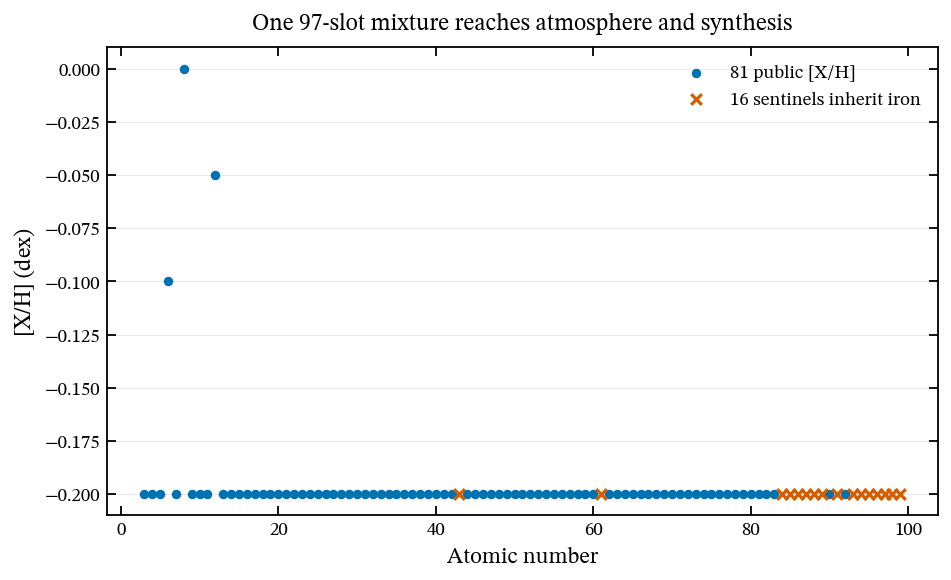

In [17]:
mixture = direct_mixture_checkpoint()
z = np.arange(3, 100)
public_mask = np.isin(z, mixture.layout.public_atomic_numbers)
figure, axes = single_panel()
axes.scatter(z[public_mask], mixture.exact_mixture[public_mask],
             s=18, label="81 public [X/H]")
axes.scatter(z[~public_mask], mixture.exact_mixture[~public_mask],
             marker="x", s=35, color=PAPER_COLORS["orange"],
             label="16 sentinels inherit iron")
axes.set(xlabel="Atomic number", ylabel=r"$[\mathrm{X}/\mathrm{H}]$ (dex)",
         title="One 97-slot mixture reaches atmosphere and synthesis")
add_quiet_grid(axes, axis="y")
axes.legend()
print("dimensions:",
      mixture.layout.public_abundance_count,
      mixture.layout.network_feature_count,
      mixture.layout.exact_mixture_count)
plt.show()
plt.close(figure)


Every abundance is placed on a 0.01-dex lattice before network
evaluation, caching, deck construction, or hashing:

\[
q(x)=0.01\,\operatorname{round}(x/0.01).
\]

The implementation uses NumPy rounding, including ties to the
nearest even integer. Canonicalizing signed zero ensures that
`-0.00` and `+0.00` cannot create different mixture hashes.


In [18]:
half_steps = np.asarray(
    [-0.025, -0.015, -0.005, 0.005, 0.015, 0.025]
)
for value, quantized in zip(
    half_steps, quantize_centidex(half_steps), strict=True
):
    print(f"{value:+.3f} dex -> {quantized:+.2f} dex")
print("sentinel minus iron:",
      mixture.layout.maximum_sentinel_difference_from_iron)
print("mixture SHA-256:", mixture.mixture_sha256)


-0.025 dex -> -0.02 dex
-0.015 dex -> -0.02 dex
-0.005 dex -> +0.00 dex
+0.005 dex -> +0.00 dex
+0.015 dex -> +0.02 dex
+0.025 dex -> +0.02 dex
sentinel minus iron: 0.0
mixture SHA-256: 05a05a529330d6b3fba14383e5916e35ae45183289267fa833d2f4d9359eae46


## 14.7 An element-aware set encoder

A dense layer with 80 anonymous abundance inputs would make
element identity implicit in column position. The direct model
makes that identity explicit. Each non-Fe element receives a
learned embedding and its standardized abundance amplitude
\(a=[{\rm X/Fe}]\). A shared response law sees

\[
(\text{four stellar-state features},\,
  \text{element embedding},\,a,\,a^2)
\]

and returns linear and quadratic latent responses. The 80 element
responses are summed, joined to the four state features, and
mapped to 160 standardized coefficients. The direct checkpoint
then uses its own coefficient scales, coordinate normalization,
and PCA basis. It shares the \((160,480)\) shape and the final six
physical profile definitions with the other families, not their
trained arrays.

The summation is the load-bearing choice. A mixture is a *set*: the
periodic table has a conventional order, but a star does not care
which element we happen to list first, so the predicted atmosphere
must not either. Addition is the natural operation with that
symmetry built in — it gives the same answer for every ordering of
its arguments. A design that concatenated the 80 responses instead,
or fed them through anything sequential, would have to *learn* that
invariance from data, spending capacity discovering a symmetry we
already know exactly. Supplying both \(a\) and \(a^2\) to the shared
law then lets one element's contribution curve without needing a
separate model per element.

Reordering complete identity–abundance pairs changes only the
floating-point summation order. Reordering abundances without
their element identities describes a different mixture and must
change the output.


In [19]:
set_encoder = direct_set_encoder_checkpoint()
print("stellar state:       ", set_encoder.state_shape)
print("relative abundances: ", set_encoder.relative_abundance_shape)
print("element embeddings:  ", set_encoder.element_embedding_shape)
print("token inputs:        ", set_encoder.token_input_shape)
print("linear/quadratic law:", set_encoder.response_law_shape)
print("summed response:     ", set_encoder.summed_response_shape)
print("PCA output:          ", set_encoder.output_shape)
print("manual forward diff: ",
      set_encoder.maximum_manual_output_difference)
print("paired permutation diff:",
      set_encoder.paired_permutation_output_difference)
print("abundance-only permutation diff:",
      set_encoder.abundance_only_permutation_output_difference)


stellar state:        (1, 4)
relative abundances:  (1, 80)
element embeddings:   (80, 64)
token inputs:         (1, 80, 70)
linear/quadratic law: (1, 80, 2, 128)
summed response:      (1, 128)
PCA output:           (1, 160)
manual forward diff:  0.0
paired permutation diff: 1.7881393432617188e-07
abundance-only permutation diff: 0.1952018141746521


In [20]:
direct = direct_decoder_checkpoint()
print("network features:", direct.feature_vector.shape,
      direct.standardized_coefficients.dtype)
print("PCA coefficients:", direct.standardized_coefficients.shape)
print("physical coordinates:", direct.pca_trace.coordinates.shape,
      direct.pca_trace.coordinates.dtype)
print("independent decoder diff:",
      direct.maximum_absolute_decode_difference)
print("direct gradient-loss weight:",
      direct.derivative_loss_weight)


network features: (84,) float32
PCA coefficients: (160,)
physical coordinates: (80, 6) float64
independent decoder diff: 0.0
direct gradient-loss weight: 0.2


Direct input is strict at this low-level boundary: all 81 public
values are required, and missing, unknown, noninteger, or nonfinite
entries raise. Its support is also strict:

- \(4000\le T_{\rm eff}\le10500\) K;
- \(0.7\le\log g\le5.3\);
- \(0.5\le\xi\le4.0\) km s\(^{-1}\);
- \(-2.5\le[{\rm Fe/H}]\le0.5\);
- \(-0.5\le[{\rm X/Fe}]\le0.5\).

Unlike the ordinary/CNO route, an unsupported direct mixture is
never projected and never sent to a smaller family. Either action
would erase the abundance pattern the user requested.

The checkpoint is experimental and did not pass its frozen release
gate. Every public entry point therefore requires explicit opt-in.
The optimizer-only object carries immutable hashes and three
non-negotiable declarations:

- its role is `experimental_direct_xh_optimizer_surrogate`;
- `exact_closure_required` is true;
- `is_final_atmosphere` is false.


In [21]:
safety = direct_safety_checkpoint()
print("default call rejected:", safety.opt_in_rejected_by_default)
print("incomplete 81-vector rejected:",
      safety.incomplete_public_vector_rejected)
print("unsupported point rejected:",
      safety.unsupported_state_rejected)
print("release gate passed:", safety.release_gate_passed)
print("role:", safety.role)
print("exact closure required:", safety.exact_closure_required)
print("is final atmosphere:", safety.is_final_atmosphere)
print("realized mixture writeable:",
      safety.realized_mixture_writeable)
print("public decoded object:", safety.public_deck_type)
print("exact trials after selection:", safety.exact_trial_count)


default call rejected: True
incomplete 81-vector rejected: True
unsupported point rejected: True
release gate passed: False
role: experimental_direct_xh_optimizer_surrogate
exact closure required: True
is final atmosphere: False
realized mixture writeable: False
public decoded object: str
exact trials after selection: 1


## 14.8 The last arrow must return to physics

The intended direct physical route runs one exact trial with the
same quantized 97-slot mixture. It returns an atmosphere result
only if structural convergence succeeds and the terminal mixture
hash still matches. Otherwise it raises and produces no physical
result.

The shared full-runner finalization seam from Chapter 13 is now
present. That makes the restart trajectory executable, but it does
not promote a decoded seed by itself: the exact solver must still
run, meet its convergence gates, preserve the mixture identity,
and return a physical product.


In [22]:
closure = closure_seam_checkpoint()
print("initializer reader core:",
      closure.initializer_reader_core_executable)
print("exact restart trajectory:",
      closure.exact_restart_trajectory_executable)
print("status:", closure.status)
print("missing shared symbols:",
      ", ".join(closure.runner_symbols_missing) or "none")


initializer reader core: True
exact restart trajectory: True
status: ready
missing shared symbols: none


## 14.9 Chapter summary

1. A learned initializer chooses
   \(\mathbf{x}^{(0)}\); only the exact map
   \(\mathcal G\) can establish the fixed point
   \(\mathbf{x}_\star\).
2. Six physical profiles are transformed to respect positivity,
   monotone column mass, a grey temperature scale, and signed
   radiative acceleration.
3. The \((80,6)\) coordinates flatten in C order to 480 values and
   are represented by 160 PCA coefficients. Five-label, CNO8, and
   direct checkpoints own distinct normalization and PCA arrays.
4. The SiLU network runs in Torch `float32`. One device-to-CPU
   crossing is followed by NumPy `float64` PCA reconstruction and
   physical decoding.
5. The five-label route handles ordinary mixtures; any explicit
   C, N, or O information selects the CNO-aware route. There is no
   information-losing family fallback.
6. Ordinary/CNO support projection changes only the initializer
   query. Deterministic hashed jitters provide ordered restart
   candidates while the requested physical labels stay fixed.
7. Fixed-column format/parse quantization is part of every solver
   seed. A decoded `ModelAtmosphere` has not earned convergence.
8. Direct abundance uses an exact 81-public, 84-network,
   97-physical layout, with 16 explicit iron-inheriting sentinels
   and a 0.01-dex lattice.
9. The set encoder binds each abundance to element identity and
   sums learned linear and quadratic element responses.
10. Direct initialization is experimental, opt-in, hash-bound,
    unsupported outside its declared domain, and requires one
    exact closure trial at the identical mixture.

### Next: carry one verified atmosphere into synthesis

We now know how labels become honest candidate structures and why
no candidate is itself a physical product. [Chapter 15 assembles
the complete route from stellar labels through accepted atmosphere
to a verified spectrum.](/reader.html?ch=15)
